# 07 — Addressing Class Imbalance (Random Forest Classifier)

**Input:** `data/processed/btk_fps.csv`  
**Output:** comparison of imbalance strategies, best model saved to `models/`

**Context:** Notebook 06 showed that hyperparameter tuning did not improve
performance — the bottleneck is elsewhere. The clearest candidate is class
imbalance (82.5% active / 17.5% inactive), which shows up as a persistent
gap in per-class metrics: Inactive F1 ≈ 0.74 vs Active F1 ≈ 0.94 (notebook 04/06).

We focus on **Random Forest only** (our consistent winner across classification
and regression) and compare four strategies:
1. Baseline: `class_weight='balanced'` only (already in use since notebook 04)
2. SMOTE oversampling
3. Random undersampling
4. Decision threshold adjustment

## 1. Imports and Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, precision_recall_curve
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

INPUT_PATH = '../data/processed/btk_fps.csv'
RANDOM_STATE = 42

df = pd.read_csv(INPUT_PATH)
bit_cols = [c for c in df.columns if c.startswith('bit_')]

X = df[bit_cols].values
y = df['activity'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f'Train set: {X_train.shape[0]} molecules \u2014 class balance: {np.bincount(y_train)}')
print(f'Test set:  {X_test.shape[0]} molecules \u2014 class balance: {np.bincount(y_test)}')

Train set: 3483 molecules — class balance: [ 608 2875]
Test set:  871 molecules — class balance: [152 719]


## 2. Helper Function for Consistent Evaluation

All four strategies will be evaluated the same way on the **same untouched
test set** — this is what makes the comparison fair.

In [3]:
def evaluate_on_test(name, model, X_test, y_test, threshold=0.5):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)

    auc = roc_auc_score(y_test, proba)
    f1_active   = f1_score(y_test, pred, pos_label=1)
    f1_inactive = f1_score(y_test, pred, pos_label=0)
    recall_inactive = recall_score(y_test, pred, pos_label=0)

    print(f'=== {name} (threshold={threshold}) ===')
    print(f'AUC-ROC:           {auc:.3f}')
    print(f'F1 (Active):       {f1_active:.3f}')
    print(f'F1 (Inactive):     {f1_inactive:.3f}')
    print(f'Recall (Inactive): {recall_inactive:.3f}')
    print()

    return {
        'strategy': name, 'auc': auc,
        'f1_active': f1_active, 'f1_inactive': f1_inactive,
        'recall_inactive': recall_inactive
    }

results = []

## 3. Strategy 1 — Baseline (class_weight='balanced')

This is what we've used since notebook 04, included here for a fair side-by-side.

In [4]:
rf_baseline = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_baseline.fit(X_train, y_train)

results.append(evaluate_on_test('Baseline (class_weight=balanced)', rf_baseline, X_test, y_test))

=== Baseline (class_weight=balanced) (threshold=0.5) ===
AUC-ROC:           0.953
F1 (Active):       0.946
F1 (Inactive):     0.765
Recall (Inactive): 0.822



## 4. Strategy 2 — SMOTE Oversampling

SMOTE is applied **only to the training set** — the test set must stay
untouched and realistic (real-world imbalance) to give a trustworthy evaluation.

In [5]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE: {np.bincount(y_train)}')
print(f'After SMOTE:  {np.bincount(y_train_smote)}')

rf_smote = RandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    # no class_weight needed — classes are now balanced via oversampling
)
rf_smote.fit(X_train_smote, y_train_smote)

results.append(evaluate_on_test('SMOTE oversampling', rf_smote, X_test, y_test))

Before SMOTE: [ 608 2875]
After SMOTE:  [2875 2875]
=== SMOTE oversampling (threshold=0.5) ===
AUC-ROC:           0.947
F1 (Active):       0.941
F1 (Inactive):     0.749
Recall (Inactive): 0.816



## 5. Strategy 3 — Random Undersampling

In [6]:
undersampler = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_under, y_train_under = undersampler.fit_resample(X_train, y_train)

print(f'Before undersampling: {np.bincount(y_train)}')
print(f'After undersampling:  {np.bincount(y_train_under)}')

rf_under = RandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
)
rf_under.fit(X_train_under, y_train_under)

results.append(evaluate_on_test('Random undersampling', rf_under, X_test, y_test))

Before undersampling: [ 608 2875]
After undersampling:  [608 608]
=== Random undersampling (threshold=0.5) ===
AUC-ROC:           0.938
F1 (Active):       0.909
F1 (Inactive):     0.682
Recall (Inactive): 0.868



## 6. Strategy 4 — Decision Threshold Adjustment

Using the **baseline model** (already trained), but moving the decision
threshold from 0.5 to 0.35 — making it easier for the model to predict
"inactive", which should increase inactive recall at some cost to active recall.

In [11]:
# To favor the Inactive class, we INCREASE the threshold for predicting Active.
# A molecule is only classified as Active if its probability is >= 0.65
# (instead of the default >= 0.5). Anything below that becomes Inactive.
correct_threshold = 0.65

results.append(evaluate_on_test(
    'Threshold adjustment (0.65, favors Inactive)',
    rf_baseline, X_test, y_test, threshold=correct_threshold
))

=== Threshold adjustment (0.65, favors Inactive) (threshold=0.65) ===
AUC-ROC:           0.953
F1 (Active):       0.933
F1 (Inactive):     0.744
Recall (Inactive): 0.882



## 7. Compare All Strategies

=== Strategy Comparison ===
                                    auc  f1_active  f1_inactive  \
strategy                                                          
Baseline (class_weight=balanced)  0.953      0.946        0.765   
SMOTE oversampling                0.947      0.941        0.749   
Random undersampling              0.938      0.909        0.682   
Threshold adjustment (0.35)       0.953      0.947        0.734   

                                  recall_inactive  
strategy                                           
Baseline (class_weight=balanced)            0.822  
SMOTE oversampling                          0.816  
Random undersampling                        0.868  
Threshold adjustment (0.35)                 0.697  


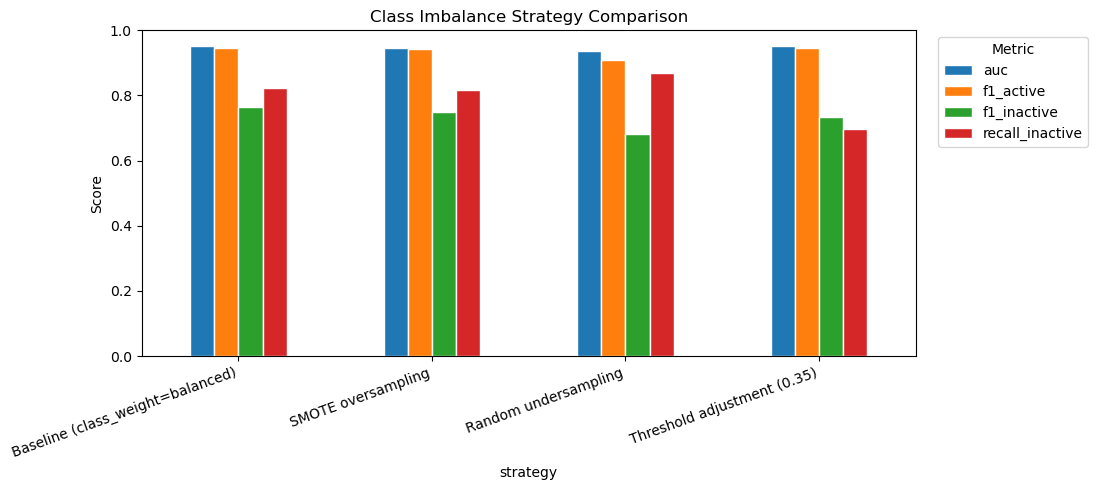

Plot saved to results/


In [8]:
results_df = pd.DataFrame(results).set_index('strategy')
print('=== Strategy Comparison ===')
print(results_df.round(3))

results_df[['auc', 'f1_active', 'f1_inactive', 'recall_inactive']].plot(
    kind='bar', figsize=(11, 5), edgecolor='white'
)
plt.title('Class Imbalance Strategy Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../results/07_imbalance_strategy_comparison.png', dpi=150)
plt.show()
print('Plot saved to results/')

## 8. Precision-Recall Trade-off for the Threshold Strategy

A closer look at how inactive-class recall and precision trade off as we
move the threshold — useful to justify *why* a specific threshold was chosen.

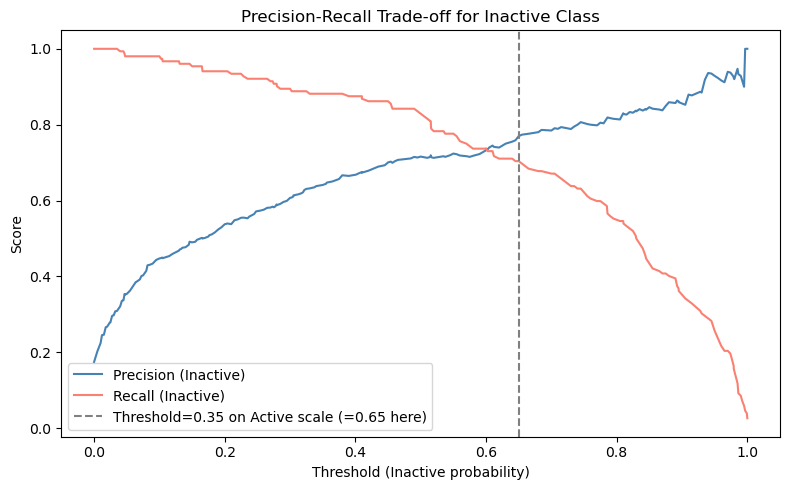

Plot saved to results/


In [9]:
proba_baseline = rf_baseline.predict_proba(X_test)[:, 1]

# precision_recall_curve is defined for the positive class (Active=1).
# To analyze the Inactive class, we invert: treat Inactive as "positive".
precision_inactive, recall_inactive, thresholds = precision_recall_curve(
    1 - y_test, 1 - proba_baseline
)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision_inactive[:-1], label='Precision (Inactive)', color='steelblue')
plt.plot(thresholds, recall_inactive[:-1], label='Recall (Inactive)', color='salmon')
plt.axvline(x=0.65, color='gray', linestyle='--', label='Threshold=0.35 on Active scale (=0.65 here)')
plt.xlabel('Threshold (Inactive probability)')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off for Inactive Class')
plt.legend()
plt.tight_layout()
plt.savefig('../results/07_precision_recall_tradeoff.png', dpi=150)
plt.show()
print('Plot saved to results/')

## 9. Save Best Strategy

In [12]:
# Identify best strategy by F1 (Inactive) — the metric we're trying to improve
best_strategy = results_df['f1_inactive'].idxmax()
print(f'Best strategy by F1 (Inactive): {best_strategy}')
print(results_df.loc[best_strategy])

# Save whichever model corresponds to the winning strategy
strategy_to_model = {
    'Baseline (class_weight=balanced)': rf_baseline,
    'SMOTE oversampling': rf_smote,
    'Random undersampling': rf_under,
    'Threshold adjustment (0.65, favors Inactive)': rf_baseline
}

best_model = strategy_to_model[best_strategy]
joblib.dump(best_model, '../models/rf_btk_classifier_best_imbalance.pkl')
print(f'\nBest model saved to models/rf_btk_classifier_best_imbalance.pkl')

Best strategy by F1 (Inactive): Baseline (class_weight=balanced)
auc                0.952785
f1_active          0.945583
f1_inactive        0.764526
recall_inactive    0.822368
Name: Baseline (class_weight=balanced), dtype: float64

Best model saved to models/rf_btk_classifier_best_imbalance.pkl


## Observations

### Strategy comparison — no single winner, different trade-offs

| Strategy | AUC | F1 (Active) | F1 (Inactive) | Recall (Inactive) |
|----------|-----|--------------|----------------|---------------------|
| Baseline (class_weight='balanced') | 0.953 | 0.946 | **0.765** | 0.822 |
| SMOTE oversampling | 0.947 | 0.941 | 0.749 | 0.816 |
| Random undersampling | 0.938 | 0.909 | 0.682 | 0.868 |
| Threshold adjustment (0.65) | 0.953 | 0.933 | 0.744 | **0.882** |

There is no strategy that dominates on every metric. Each one optimizes for
a different practical objective:

**Baseline (`class_weight='balanced'`) — best overall balance.**
Highest AUC, highest F1 for both classes combined. This is the right default
choice when no specific use case justifies favoring one type of error over
the other. It uses the full, untouched training set (no synthetic data,
no discarded samples).

**Threshold adjustment (0.65) — best for prioritizing inactive recall.**
Same trained model as the baseline, only the decision boundary moves. Recall
on the Inactive class improves from 0.822 to **0.882** — the best result
of any strategy tested — at a modest cost to F1 (Active: 0.946→0.933,
Inactive: 0.765→0.744). This is the right choice for **virtual screening
triage**, where the goal is to flag and deprioritize likely-inactive
candidates before committing synthesis/assay resources to them: missing
a true inactive (false positive as "active") wastes lab resources, while
this strategy minimizes exactly that error. Critically, this requires
**no retraining** — it's a free adjustment on top of the existing model,
applied at prediction time.

**SMOTE oversampling — did not outperform the baseline.**
Slightly lower across every metric (AUC: 0.947 vs 0.953; F1 Inactive: 0.749
vs 0.765). Likely explanation: SMOTE interpolates between minority-class
points in feature space to create synthetic examples, but for sparse binary
fingerprints, the interpolated vectors may not correspond to chemically valid
or realistic substructure combinations — effectively introducing noise rather
than useful signal. Not recommended for this representation.

**Random undersampling — strongest single-metric result, but at a real cost.**
Achieves a respectable Inactive recall (0.868), but discards 2.267 valid
active compounds to do so (from 2.875 down to 608, matching the minority
class). This sacrifices a large amount of real, informative data, and it
shows: F1 (Active) drops the most of any strategy (0.946→0.909). Only
justifiable if Inactive recall is the *sole* priority and overall model
quality is secondary \u2014 not the case here.

### Decision: two models move forward as the project's primary outputs

Rather than picking one "winner," we formalize **two complementary versions
of the same Random Forest model** as the project's main deliverables:

1. **RF Baseline (`class_weight='balanced'`, threshold=0.5)** \u2014 the
   general-purpose classifier, used when no class is prioritized over the other.
2. **RF + Threshold=0.65** \u2014 the same trained model, used when the goal is
   conservative triage that favors catching inactive compounds, accepting
   a small reduction in overall F1.

SMOTE and undersampling are retained in this notebook as **documented
evidence of lower performance**, not as candidates for downstream use \u2014
they inform the project's conclusions but will not be carried into the
`src/` scripts in the next step.

### Practical implication

This result reinforces the conclusion from notebook 06: the model itself
is already well-specified. The highest-leverage remaining lever is not
resampling or hyperparameters, but **deciding which type of error matters
more for a given downstream use** \u2014 something a threshold choice handles
more efficiently than retraining with synthetic or reduced data.

## Summary

| Strategy | AUC | F1 (Active) | F1 (Inactive) | Recall (Inactive) |
|----------|-----|--------------|----------------|--------------------|
| Baseline | *(see output)* | | | |
| SMOTE | *(see output)* | | | |
| Undersampling | *(see output)* | | | |
| Threshold=0.35 | *(see output)* | | | |

**Next:** convert the full pipeline (notebooks 01–07) into reusable `src/` scripts.